# nu over d for uniform distribution
## 1. as d increases
## 2. histogram of values for d = 1000

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [3]:
# combine these sets
arr1 = np.arange(10, 100, 1)
arr2 = np.arange(100, 200, 2)
arr3 = np.arange(200, 400, 4)
arr4 = np.arange(400, 600, 5)
arr5 = np.arange(600, 1010, 10)
combined = np.unique(np.concatenate((arr1, arr2)))
combined = np.unique(np.concatenate((combined, arr3)))
combined = np.unique(np.concatenate((combined, arr4)))
combined = np.unique(np.concatenate((combined, arr5)))
n_vals = np.array(combined)

In [4]:
num_n = n_vals.shape[0]
nu_vals = np.zeros(num_n)
nu_over_d_vals= np.zeros(num_n)
i = 0
for n in n_vals:
  samples = np.random.uniform(low = 0.0, high = 1.0, size = n)
  this_nu = pp.calculate_nu(samples)
  nu_vals[i] = this_nu
  this_nu_over_d = this_nu / (1.000 * n)
  nu_over_d_vals[i] = this_nu_over_d
  print(n, this_nu, this_nu_over_d)
  i+=1

10 7.508049959355776 0.7508049959355776
11 7.550035414423581 0.6863668558566892
12 8.447145926346947 0.7039288271955789
13 9.354157179194884 0.7195505522457603
14 10.128014934025163 0.7234296381446546
15 10.594932904834913 0.7063288603223276
16 11.722400324576808 0.7326500202860505
17 13.181398647768091 0.7753763910451819
18 13.213373613780076 0.7340763118766709
19 14.145821672563864 0.7445169301349402
20 14.608417928235665 0.7304208964117833
21 14.754390114420014 0.7025900054485721
22 16.66154385762252 0.7573429026192054
23 17.943993485705263 0.7801736298132723
24 17.877358644258592 0.7448899435107746
25 22.17398989761551 0.8869595959046204
26 18.27782055626313 0.7029930983178126
27 20.262061528097526 0.7504467232628713
28 20.00360231584059 0.7144143684228782
29 20.32291571797219 0.7007901971714549
30 24.21617131360651 0.8072057104535503
31 21.60760978811825 0.6970196705844597
32 22.72811483464189 0.710253588582559
33 25.594301363870485 0.7755848898142571
34 27.585434829551804 0.81133

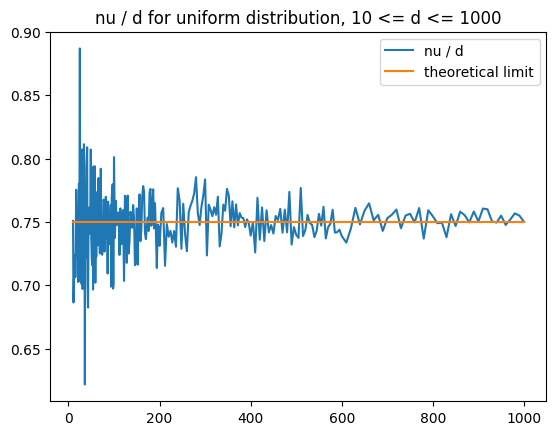

In [5]:
limit_vals = 0.75 * np.ones(len(n_vals))

this_title = "nu / d for uniform distribution, 10 <= d <= 1000"
plt.plot(n_vals, nu_over_d_vals, label="nu / d")
plt.plot(n_vals, limit_vals, label="theoretical limit")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_uniform_10_leq_d_leq_1000.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 10000 samples for d = 100

In [6]:
N = 10000 # num samples
d = 100
nu_vals = np.zeros(N)
nu_over_d_vals = np.zeros(N)

for i in range(N):
  samples = np.random.uniform(low = 0.0, high = 1.0, size = d)
  this_nu = pp.calculate_nu(samples)
  nu_vals[i] = this_nu
  this_nu_over_d = this_nu / (1.000 * d)
  nu_over_d_vals[i] = this_nu_over_d
  if i % 100 == 0:
    print(i, this_nu, this_nu_over_d)

0 76.52305866055325 0.7652305866055324
100 71.91586812917161 0.7191586812917161
200 75.68153352186945 0.7568153352186946
300 75.29234587320559 0.7529234587320559
400 73.76458967611788 0.7376458967611788
500 74.16826341708146 0.7416826341708146
600 75.85232658301918 0.7585232658301918
700 71.45045685052206 0.7145045685052206
800 76.19339468310285 0.7619339468310286
900 75.86589155380679 0.7586589155380679
1000 77.65313646887208 0.7765313646887207
1100 71.54285322463369 0.7154285322463368
1200 70.54737451922671 0.705473745192267
1300 71.95901018072541 0.7195901018072541
1400 73.29409284103012 0.7329409284103012
1500 72.45007899527576 0.7245007899527576
1600 73.59493685155542 0.7359493685155541
1700 74.55259113165458 0.7455259113165458
1800 70.28508556421593 0.7028508556421593
1900 74.72786479498167 0.7472786479498167
2000 72.62692501641473 0.7262692501641473
2100 71.83178732668344 0.7183178732668344
2200 73.66938048833305 0.7366938048833305
2300 74.27206439424258 0.7427206439424258
2400 

summary stats for input values
type : <class 'numpy.ndarray'>
shape : (10000,)
min : 0.6426399697320935
max : 0.8541965760025153
mean : 0.7512
std : 0.0272
Histogram counts: [  0   0   0   0   0   0   0   0   0   0   1   0   1   1   0   2   1   6
   7   5   8   3  11  14  27  23  19  36  43  43  48  52  72  92 104 106
 144 176 181 209 188 235 284 290 307 346 340 361 379 377 353 389 370 366
 390 338 354 345 308 279 274 231 208 203 175 152 167 108  88  79  60  55
  41  31  24  15  15  12   7   6   2   5   3   3   0   0   0   1   0   0
   1   0   0   0   0   0   0   0   0   0]


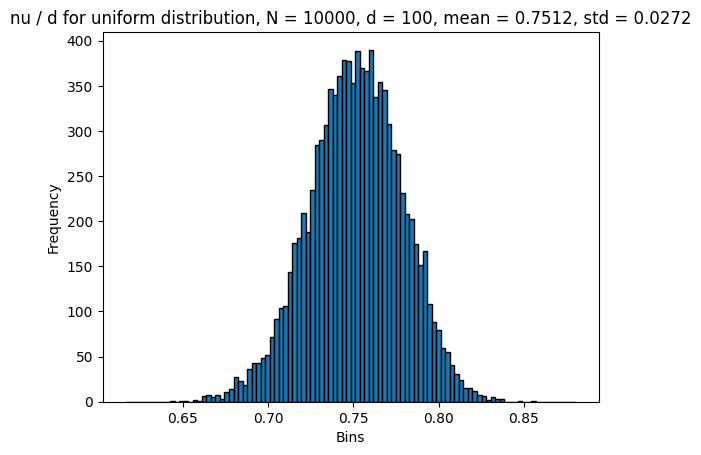

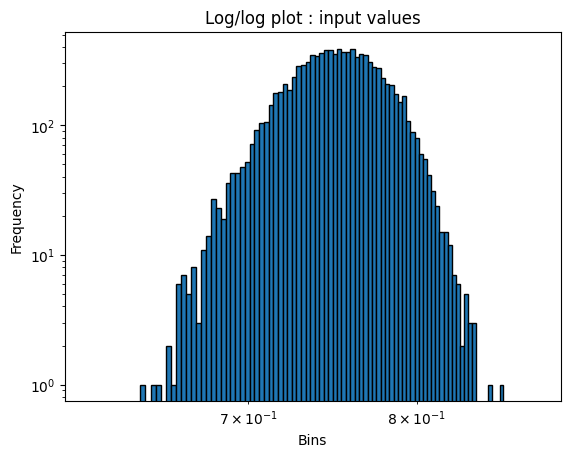

In [9]:
this_title_text = "nu / d for uniform distribution, N = " + str(N) + ", d = " + str(d)
this_image_name="nu_over_d_uniform_N_" + str(N) + "_d_" + str(d)

pp.plot_histogram_of_values(nu_over_d_vals, num_bins = 100, title_text = this_title_text, image_name = this_image_name)